# 06 — Feature Selection: What to Add/Remove

**Goal:** Decide which features to add from Lending Club and which to remove.

**Note:** SHAP analysis for model explanation is in notebook 03. Here we focus on feature selection.

**What we analyze:**
1. Feature correlation (redundancy check)
2. Feature gaps (what's missing from Lending Club)
3. Recommendations (what to add/remove)

**Run:** `docker compose exec airflow-scheduler jupyter notebook notebooks/06_feature_selection.ipynb --allow-root`

In [3]:
import sys
from pathlib import Path

# Handle both Docker and local execution
docker_path = Path('/opt/airflow')
if docker_path.exists():
    sys.path.insert(0, str(docker_path))
else:
    ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
    sys.path.insert(0, str(ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import get_db_engine, TrainingConfig, ARTIFACTS_DIR, FeatureConfig
from src.data.queries import get_feature_dataset

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.figsize'] = (14, 6)

print('✅ Modules loaded')

✅ Modules loaded


## 1. Load current features

In [4]:
# Load validation data
engine = get_db_engine()
train, val, test = get_feature_dataset(engine, TrainingConfig.TRAIN_END_DATE, TrainingConfig.VAL_END_DATE)

print(f'✅ Validation set: {len(val)} rows')
print(f'\n📊 Current Features ({len(FeatureConfig.ALL_FEATURES)} total):')
print(f'   - Numerical: {len(FeatureConfig.NUMERICAL_FEATURES)}')
print(f'   - Target Encoded: {len(FeatureConfig.TARGET_ENCODED_FEATURES)}')
print(f'   - Aggregation: {len(FeatureConfig.AGGREGATION_FEATURES)}')
print(f'   - Bureau: {len(FeatureConfig.BUREAU_FEATURES)}')

print(f'\n📝 Feature List:')
for i, feat in enumerate(FeatureConfig.ALL_FEATURES, 1):
    print(f'   {i:2d}. {feat}')

✅ Validation set: 64113 rows

📊 Current Features (27 total):
   - Numerical: 16
   - Target Encoded: 2
   - Aggregation: 7
   - Bureau: 2

📝 Feature List:
    1. loan_to_income
    2. credit_utilization
    3. income_log
    4. loan_amount_log
    5. dti_ratio_clipped
    6. employment_years
    7. credit_score_norm
    8. num_open_accounts
    9. num_delinquencies
   10. interest_rate
   11. loan_term
   12. num_inquiries_6m
   13. loan_amount_x_dti
   14. income_x_credit_score
   15. dti_x_credit_score
   16. loan_amount_x_interest_rate
   17. purpose_target_enc
   18. home_ownership_target_enc
   19. avg_days_overdue_30d
   20. avg_days_overdue_90d
   21. avg_days_overdue_180d
   22. max_days_overdue_90d
   23. pct_late_payments_90d
   24. total_paid_90d
   25. payment_consistency_90d
   26. bureau_balance_to_income
   27. inquiries_per_account


## 2. Feature Correlation Analysis (Redundancy Check)

🔍 Computing correlation matrix...

📊 Highly Correlated Pairs (|r| > 0.7):
                   feature1             feature2  correlation
       max_days_overdue_90d avg_days_overdue_90d     0.985309
         dti_x_credit_score    loan_amount_x_dti     0.837879
   bureau_balance_to_income       loan_to_income     0.824422
loan_amount_x_interest_rate      loan_amount_log     0.743846
      pct_late_payments_90d avg_days_overdue_90d     0.741980
    payment_consistency_90d       total_paid_90d     0.725174
      pct_late_payments_90d max_days_overdue_90d     0.721502

💡 Found 7 highly correlated pairs
   These features may be redundant — consider removing one from each pair


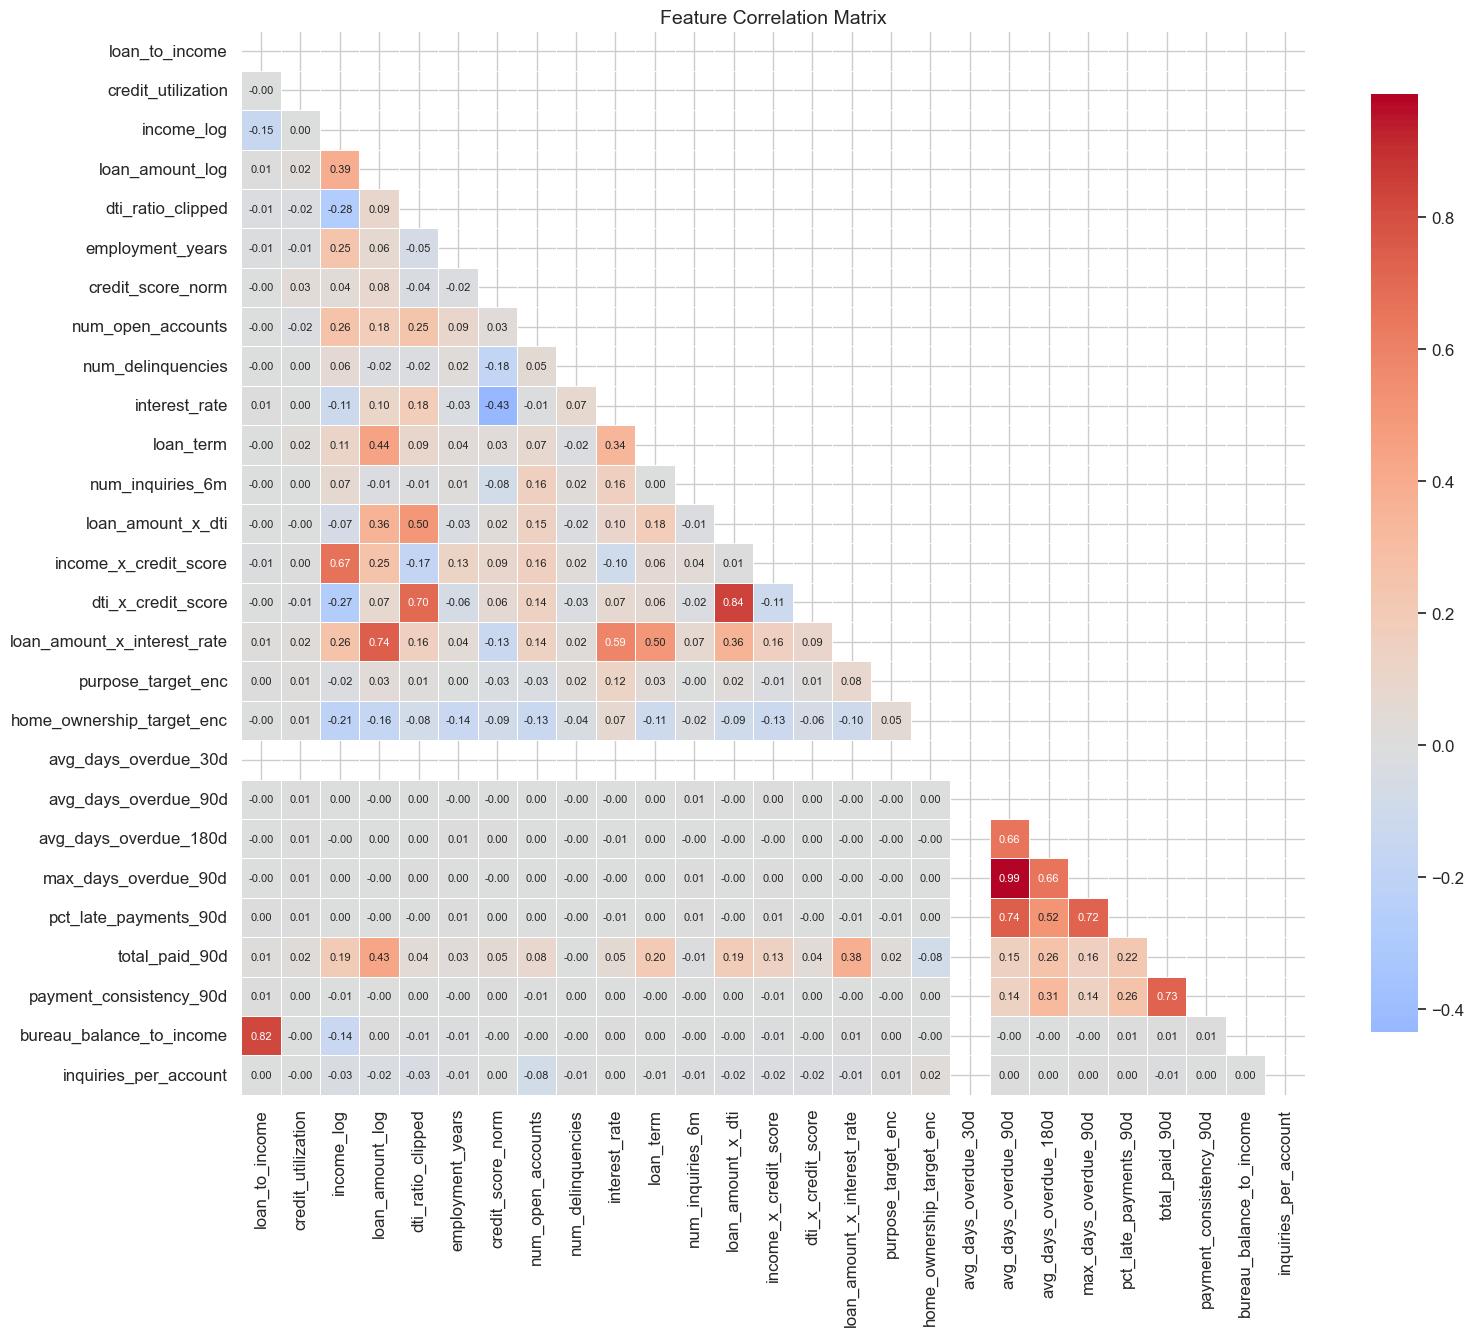

In [5]:
# Correlation matrix
print('🔍 Computing correlation matrix...')

feature_cols = FeatureConfig.ALL_FEATURES
X_val = val[feature_cols].copy()

# Fill NaN for correlation
X_val = X_val.fillna(X_val.median())

corr_matrix = X_val.corr()

# Find highly correlated pairs (>0.7)
high_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) > 0.7:
            col1 = corr_matrix.columns[i]
            col2 = corr_matrix.columns[j]
            high_corr.append({
                'feature1': col1,
                'feature2': col2,
                'correlation': corr_matrix.iloc[i, j]
            })

high_corr_df = pd.DataFrame(high_corr).sort_values('correlation', ascending=False)

print(f'\n📊 Highly Correlated Pairs (|r| > 0.7):')
if len(high_corr_df) > 0:
    print(high_corr_df.to_string(index=False))
    print(f'\n💡 Found {len(high_corr_df)} highly correlated pairs')
    print('   These features may be redundant — consider removing one from each pair')
else:
    print('   None')

# Plot correlation heatmap
plt.figure(figsize=(16, 14))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8},
            annot_kws={'size': 8})
plt.title('Feature Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.show()

## 3. Permutation Importance (Feature Importance)

🔍 Computing permutation importance...


c:\Users\pc\Downloads\credit-scoring-master\src\models\scoring\artifacts.py:81: UserWarning: [21:27:56] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\gbm\../common/error_msg.h:83: If you are loading a serialized model (like pickle in Python, RDS in R) or
configuration generated by an older version of XGBoost, please export the model by calling
`Booster.save_model` from that version first, then load it back in current version. See:

    https://xgboost.readthedocs.io/en/stable/tutorials/saving_model.html

for more details about differences between saving model and serializing.

  model = pickle.load(f)
c:\Users\pc\anaconda1\Lib\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to unpickle estimator IsotonicRegression from version 1.4.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  wa


📊 Top 20 Features by Permutation Importance:
                    feature  importance      std
              interest_rate    0.066022 0.001374
         credit_utilization    0.008842 0.000824
             loan_to_income    0.006247 0.001552
  home_ownership_target_enc    0.006170 0.000878
           num_inquiries_6m    0.005760 0.000451
          credit_score_norm    0.004781 0.000719
           employment_years    0.002065 0.000190
          num_open_accounts    0.001428 0.000580
loan_amount_x_interest_rate    0.001427 0.000343
          dti_ratio_clipped    0.001354 0.000572
             total_paid_90d    0.000722 0.000281
      income_x_credit_score    0.000696 0.000304
          loan_amount_x_dti    0.000675 0.000369
                 income_log    0.000509 0.000167
            loan_amount_log    0.000470 0.000156
         purpose_target_enc    0.000320 0.000142
         dti_x_credit_score    0.000267 0.000114
   bureau_balance_to_income    0.000235 0.000127
          num_delinquen

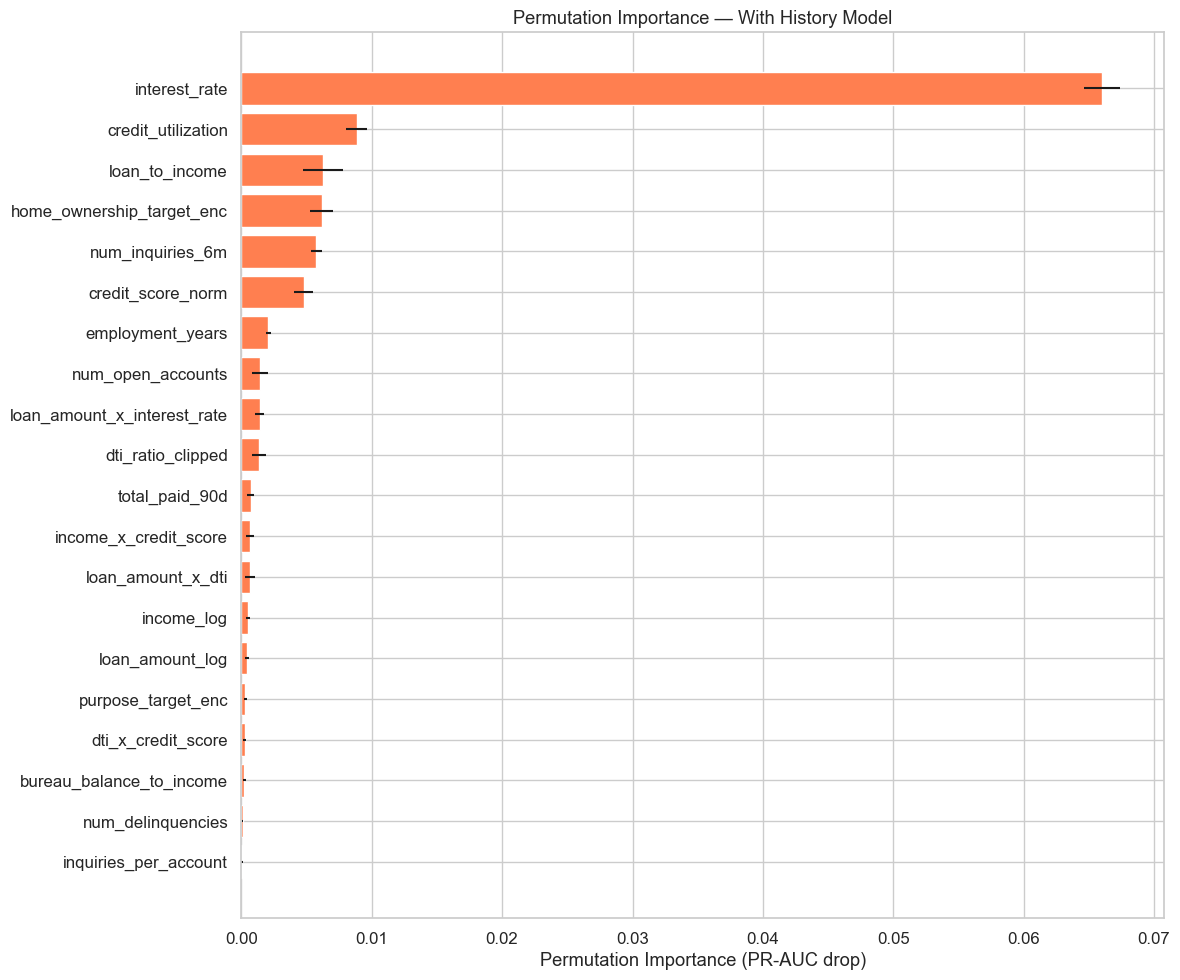


⚠️  Low Importance Features (<10% of median):
                feature  importance      std
   max_days_overdue_90d    0.000000 0.000000
   avg_days_overdue_30d    0.000000 0.000000
  avg_days_overdue_180d    0.000000 0.000000
  pct_late_payments_90d    0.000000 0.000000
   avg_days_overdue_90d   -0.000011 0.000008
payment_consistency_90d   -0.000013 0.000011
              loan_term   -0.000412 0.000529

💡 Can potentially remove 7 low-importance features


In [6]:
# Permutation importance
print('🔍 Computing permutation importance...')

from sklearn.inspection import permutation_importance
from src.models.scoring.artifacts import ScoringArtifact

# Load model
model_path = ARTIFACTS_DIR / 'with_history'
artifact = ScoringArtifact.load(model_path)
model = artifact.model

# Prepare features
X_val = val[FeatureConfig.ALL_FEATURES].copy()
X_val = X_val.fillna(X_val.median())
y_val = val[TrainingConfig.TARGET_COL].astype(int)

# Compute permutation importance
result = permutation_importance(
    model, X_val, y_val,
    n_repeats=10,
    random_state=42,
    scoring='average_precision'
)

perm_importance = pd.DataFrame({
    'feature': FeatureConfig.ALL_FEATURES,
    'importance': result.importances_mean,
    'std': result.importances_std
}).sort_values('importance', ascending=False)

print(f'\n📊 Top 20 Features by Permutation Importance:')
print(perm_importance.head(20).to_string(index=False))

# Plot
plt.figure(figsize=(12, 10))
plt.barh(perm_importance['feature'][:20][::-1], perm_importance['importance'][:20][::-1], 
         xerr=perm_importance['std'][:20][::-1], color='coral')
plt.xlabel('Permutation Importance (PR-AUC drop)')
plt.title('Permutation Importance — With History Model')
plt.tight_layout()
plt.show()

# Low importance features
low_importance = perm_importance[perm_importance['importance'] < perm_importance['importance'].median() * 0.1]
print(f'\n⚠️  Low Importance Features (<10% of median):')
if len(low_importance) > 0:
    print(low_importance.to_string(index=False))
    print(f'\n💡 Can potentially remove {len(low_importance)} low-importance features')
else:
    print('   None')

## 4. Feature Category Analysis

📊 Feature Importance by Category:
      category  n_features  total_importance  avg_importance
     Numerical          16          0.100225        0.006264
Target Encoded           2          0.006490        0.003245
   Aggregation           7          0.000698        0.000100
        Bureau           2          0.000309        0.000155


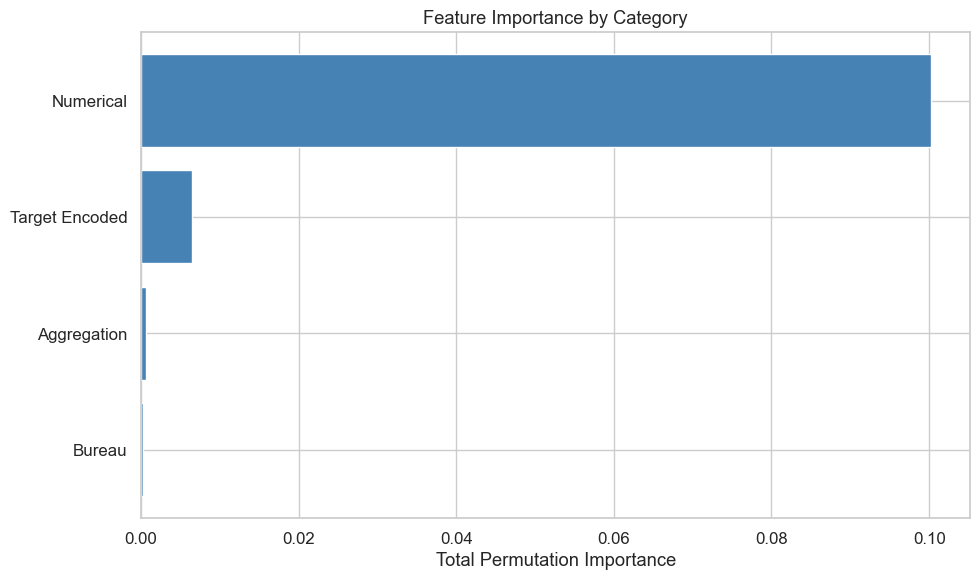

In [7]:
# Group features by category
categories = {
    'Numerical': FeatureConfig.NUMERICAL_FEATURES,
    'Target Encoded': FeatureConfig.TARGET_ENCODED_FEATURES,
    'Aggregation': FeatureConfig.AGGREGATION_FEATURES,
    'Bureau': FeatureConfig.BUREAU_FEATURES
}

category_importance = []
for cat_name, cat_features in categories.items():
    cat_imp = perm_importance[perm_importance['feature'].isin(cat_features)]['importance'].sum()
    category_importance.append({
        'category': cat_name,
        'n_features': len(cat_features),
        'total_importance': cat_imp,
        'avg_importance': cat_imp / len(cat_features) if len(cat_features) > 0 else 0
    })

cat_df = pd.DataFrame(category_importance).sort_values('total_importance', ascending=False)

print('📊 Feature Importance by Category:')
print(cat_df.to_string(index=False))

# Plot
plt.figure(figsize=(10, 6))
plt.barh(cat_df['category'][::-1], cat_df['total_importance'][::-1], color='steelblue')
plt.xlabel('Total Permutation Importance')
plt.title('Feature Importance by Category')
plt.tight_layout()
plt.show()

## 5. Feature Gap Analysis

In [8]:
print('🔍 Analyzing feature gaps...')

print('\n📊 Current Feature Categories:')
print('   ✅ Numerical: loan_to_income, credit_utilization, income_log, etc.')
print('   ✅ Target Encoded: purpose, home_ownership')
print('   ✅ Aggregation: avg_days_overdue, pct_late_payments, etc.')
print('   ✅ Bureau: bureau_balance_to_income, inquiries_per_account')

print('\n❌ Missing Features from Lending Club:')
print()
print('   🎯 HIGH PRIORITY (expected +0.03-0.05 AUC each):')
print('   1. grade / sub_grade (A-G, A1-G5)')
print('      - Internal LC risk rating')
print('      - Very predictive for default')
print('      - Add as: target encoding')
print()
print('   2. pub_rec_bankruptcies')
print('      - Public records (bankruptcies)')
print('      - Strong predictor of default')
print('      - Add as: binary flag + count')
print()
print('   🎯 MEDIUM PRIORITY (expected +0.01-0.02 AUC each):')
print('   3. revolving_utilization (revol_util)')
print('      - Revolving balance / total credit limit')
print('      - High utilization = high risk')
print('      - Add as: numerical feature')
print()
print('   4. verification_status')
print('      - Income/employment verified?')
print('      - Verified clients are less risky')
print('      - Add as: binary encoding')
print()
print('   🎯 LOW PRIORITY (expected +0.005-0.01 AUC each):')
print('   5. total_accounts / mort_acc')
print('      - Number of accounts, mortgages')
print('      - More accounts = more experience')
print('      - Add as: log-transformed numerical')
print()
print('   6. Interaction features:')
print('      - credit_score × income')
print('      - loan_amount × credit_score')
print('      - dti × interest_rate')
print('      - Add as: cross features')

🔍 Analyzing feature gaps...

📊 Current Feature Categories:
   ✅ Numerical: loan_to_income, credit_utilization, income_log, etc.
   ✅ Target Encoded: purpose, home_ownership
   ✅ Aggregation: avg_days_overdue, pct_late_payments, etc.
   ✅ Bureau: bureau_balance_to_income, inquiries_per_account

❌ Missing Features from Lending Club:

   🎯 HIGH PRIORITY (expected +0.03-0.05 AUC each):
   1. grade / sub_grade (A-G, A1-G5)
      - Internal LC risk rating
      - Very predictive for default
      - Add as: target encoding

   2. pub_rec_bankruptcies
      - Public records (bankruptcies)
      - Strong predictor of default
      - Add as: binary flag + count

   🎯 MEDIUM PRIORITY (expected +0.01-0.02 AUC each):
   3. revolving_utilization (revol_util)
      - Revolving balance / total credit limit
      - High utilization = high risk
      - Add as: numerical feature

   4. verification_status
      - Income/employment verified?
      - Verified clients are less risky
      - Add as: binary e

## 6. Recommendations

In [9]:
print('='*80)
print('📋 FEATURE SELECTION RECOMMENDATIONS')
print('='*80)

print('\n✅ REMOVE (if highly correlated and low importance):')
if len(high_corr_df) > 0:
    print('   Highly correlated pairs found — review correlation heatmap')
    print('   Consider removing one feature from each pair with |r| > 0.8')
    for _, row in high_corr_df[high_corr_df['correlation'].abs() > 0.8].iterrows():
        print(f'   - {row["feature1"]} ↔ {row["feature2"]} (r={row["correlation"]:.2f})')
else:
    print('   None — no highly correlated features found')

print('\n➕ ADD (in priority order):')
print('   1. grade / sub_grade (target encoding) — HIGHEST PRIORITY')
print('   2. has_bankruptcy (binary) — HIGH PRIORITY')
print('   3. revolving_utilization (numerical) — MEDIUM PRIORITY')
print('   4. verification_status (binary) — MEDIUM PRIORITY')
print('   5. Interaction features — LOW PRIORITY')

print('\n📊 Expected Impact:')
print('   - Adding grade/sub_grade: +0.03-0.05 PR-AUC')
print('   - Adding bankruptcy: +0.02-0.03 PR-AUC')
print('   - Adding utilization: +0.01-0.02 PR-AUC')
print('   - Total expected improvement: +0.06-0.10 PR-AUC')

print('\n🔧 Implementation Steps:')
print('   1. Check if features exist in lending_club.csv')
print('   2. Update COLUMN_MAP in src/data/ingestion.py')
print('   3. Add feature engineering in src/features/numerical.py')
print('   4. Update FeatureConfig in src/config.py')
print('   5. Re-run data_ingestion → feature_engineering → model_training')
print('   6. Re-evaluate model performance')

print('\n' + '='*80)
print('✅ Feature selection analysis complete!')
print('='*80)

📋 FEATURE SELECTION RECOMMENDATIONS

✅ REMOVE (if highly correlated and low importance):
   Highly correlated pairs found — review correlation heatmap
   Consider removing one feature from each pair with |r| > 0.8
   - max_days_overdue_90d ↔ avg_days_overdue_90d (r=0.99)
   - dti_x_credit_score ↔ loan_amount_x_dti (r=0.84)
   - bureau_balance_to_income ↔ loan_to_income (r=0.82)

➕ ADD (in priority order):
   1. grade / sub_grade (target encoding) — HIGHEST PRIORITY
   2. has_bankruptcy (binary) — HIGH PRIORITY
   3. revolving_utilization (numerical) — MEDIUM PRIORITY
   4. verification_status (binary) — MEDIUM PRIORITY
   5. Interaction features — LOW PRIORITY

📊 Expected Impact:
   - Adding grade/sub_grade: +0.03-0.05 PR-AUC
   - Adding bankruptcy: +0.02-0.03 PR-AUC
   - Adding utilization: +0.01-0.02 PR-AUC
   - Total expected improvement: +0.06-0.10 PR-AUC

🔧 Implementation Steps:
   1. Check if features exist in lending_club.csv
   2. Update COLUMN_MAP in src/data/ingestion.py
   3